In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)

In [16]:
# LOAD DATA

urbanev_master = pd.read_csv(
    "urbanev_master.csv"
)

urbanev_master['timestamp'] = pd.to_datetime(
    urbanev_master['timestamp']
)

print(urbanev_master.shape)

display(
    urbanev_master.head())

(2134080, 19)


,timestamp,station_id,volume,occupancy,duration,energy_cost_per_kwh,num,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing,utilization_rate,revenue,occupancy_density,queue_proxy
0,2022-06-19 00:00:00,102,2.858333,12,0.49,0.924,1,30,3,27,0.71,114.103,22.54041,0,0,0.4,2.6411,0.4,1.143333
1,2022-06-19 00:05:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0,0.4,4.0425,0.4,1.750000
2,2022-06-19 00:10:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0,0.4,4.0425,0.4,1.750000
3,2022-06-19 00:15:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0,0.4,4.0425,0.4,1.750000
4,2022-06-19 00:20:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0,0.4,4.0425,0.4,1.750000


In [18]:
# VERIFY REQUIRED COLUMNS

required_cols = [

    'utilization_rate',
    'occupancy_density',
    'queue_proxy'

]

for col in required_cols:

    print(
        col,
        "✓" if col in urbanev_master.columns else "✗"
    )

utilization_rate ✓
occupancy_density ✓
queue_proxy ✓


In [19]:
# CREATE DEMAND SCORE

scaler = MinMaxScaler()

score_features = [

    'utilization_rate',
    'occupancy_density',
    'queue_proxy'

]

scaled_cols = [
    col + '_scaled'
    for col in score_features
]

urbanev_master[
    scaled_cols
] = scaler.fit_transform(
    urbanev_master[
        score_features
    ]
)

urbanev_master['demand_score'] = (

      0.40 * urbanev_master[
          'utilization_rate_scaled'
      ]

    + 0.30 * urbanev_master[
          'occupancy_density_scaled'
      ]

    + 0.30 * urbanev_master[
          'queue_proxy_scaled'
      ]

)

display(
    urbanev_master[
        ['demand_score']
    ].describe()
)

,demand_score
count,2.134080e+06
mean,1.859626e-01
std,1.205568e-01
min,0.000000e+00
25%,9.899650e-02
50%,1.626328e-01
75%,2.502410e-01
max,8.740876e-01


In [21]:
# TARIFF RECOMMENDATION ENGINE

def tariff_category(score):

    if score < 0.25:

        return "Discount"

    elif score < 0.50:

        return "Base"

    elif score < 0.75:

        return "Premium"

    else:

        return "Peak Premium"

In [22]:
urbanev_master['tariff_category'] = (

    urbanev_master[
        'demand_score'
    ].apply(
        tariff_category
    )

)

In [23]:
# TARIFF MULTIPLIERS

multiplier_map = {

    'Discount':0.90,

    'Base':1.00,

    'Premium':1.15,

    'Peak Premium':1.30
}

urbanev_master[
    'tariff_multiplier'
] = (

    urbanev_master[
        'tariff_category'
    ].map(
        multiplier_map
    )

)

display(

    urbanev_master[
        [
            'demand_score',
            'tariff_category',
            'tariff_multiplier'
        ]
    ].head()

)

,demand_score,tariff_category,tariff_multiplier
0,0.260260,Base,1.0
1,0.260398,Base,1.0
2,0.260398,Base,1.0
3,0.260398,Base,1.0
4,0.260398,Base,1.0


In [24]:
# PRICING SUMMARY

pricing_summary = (

    urbanev_master[
        'tariff_category'
    ]

    .value_counts()

    .reset_index()

)

pricing_summary.columns = [

    'Tariff Category',
    'Count'
]

pricing_summary['Percentage'] = (

    pricing_summary['Count']

    /

    pricing_summary['Count'].sum()

    * 100

)

display(
    pricing_summary
)

,Tariff Category,Count,Percentage
0,Discount,1599953,74.971557
1,Base,491189,23.016429
2,Premium,42370,1.985399
3,Peak Premium,568,0.026616


In [26]:
# 8. STATION CONGESTION RANKING

station_scores = (

    urbanev_master

    .groupby(
        'station_id'
    )

    .agg({

        'demand_score':'mean',

        'utilization_rate':'mean',

        'occupancy_density':'mean',

        'queue_proxy':'mean'

    })

    .reset_index()

)

station_scores = (

    station_scores

    .sort_values(
        'demand_score',
        ascending=False
    )

)

display(
    station_scores.head(20)
)

,station_id,demand_score,utilization_rate,occupancy_density,queue_proxy
178,1029,0.506730,0.760269,0.760269,55.166713
104,715,0.484424,0.734580,0.734580,30.526889
227,1131,0.469652,0.582488,0.582488,400.004581
59,570,0.417291,0.639760,0.639760,6.358834
77,633,0.409562,0.541361,0.541361,253.430424
110,732,0.406099,0.614578,0.614578,29.103055
69,595,0.388777,0.453683,0.453683,412.523195
164,982,0.383891,0.589400,0.589400,3.432126
106,719,0.377149,0.579707,0.579707,1.492009
103,712,0.376837,0.575697,0.575697,11.574448


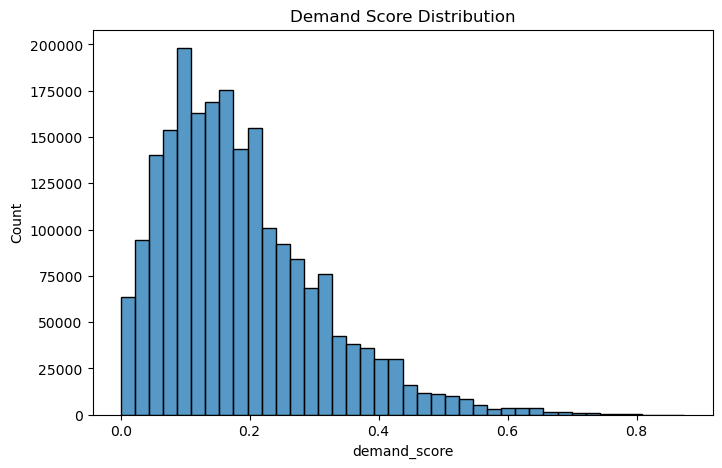

In [27]:
# DEMAND SCORE DISTRIBUTION

plt.figure(
    figsize=(8,5)
)

sns.histplot(

    urbanev_master[
        'demand_score'
    ],

    bins=40

)

plt.title(
    'Demand Score Distribution'
)

plt.show()

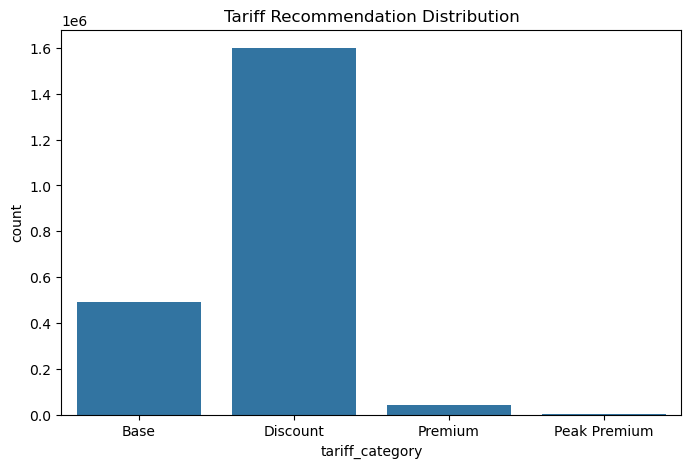

In [29]:
# TARIFF CATEGORY DISTRIBUTION

plt.figure(
    figsize=(8,5)
)

sns.countplot(

    x='tariff_category',

    data=urbanev_master

)

plt.title(
    'Tariff Recommendation Distribution'
)

plt.show()

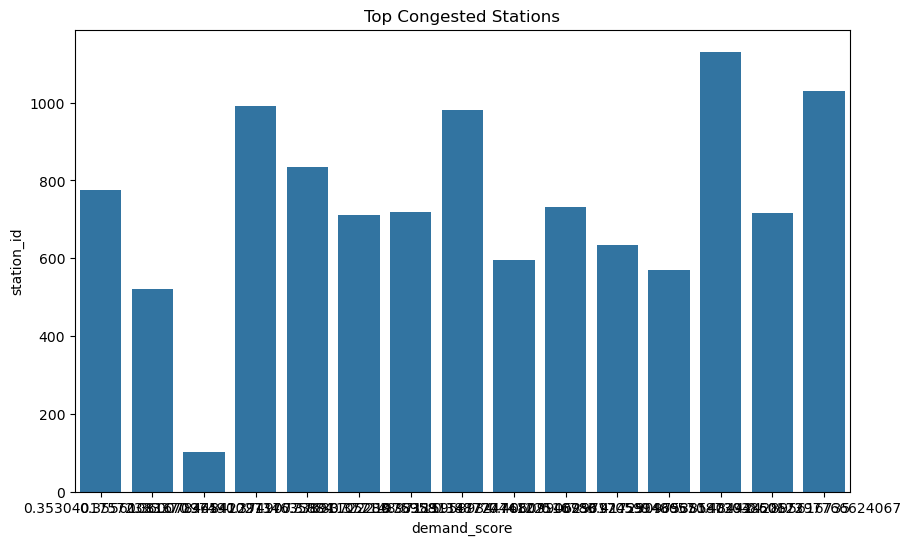

In [31]:
# TOP CONGESTED STATIONS

top_stations = (
    station_scores
    .head(15)
)

plt.figure(
    figsize=(10,6)
)

sns.barplot(

    data=top_stations,

    x='demand_score',

    y='station_id'

)

plt.title(
    'Top Congested Stations'
)

plt.show()

In [33]:
# TARIFF RECOMMENDATIONS

tariff_recommendations = (

    urbanev_master[
        [

            'timestamp',

            'station_id',

            'demand_score',

            'tariff_category',

            'tariff_multiplier'

        ]
    ]

)

display(
    tariff_recommendations.head()
)

,timestamp,station_id,demand_score,tariff_category,tariff_multiplier
0,2022-06-19 00:00:00,102,0.260260,Base,1.0
1,2022-06-19 00:05:00,102,0.260398,Base,1.0
2,2022-06-19 00:10:00,102,0.260398,Base,1.0
3,2022-06-19 00:15:00,102,0.260398,Base,1.0
4,2022-06-19 00:20:00,102,0.260398,Base,1.0


In [34]:
# 13. EXPORT RESULTS

tariff_recommendations.to_csv(
    "tariff_recommendations.csv",
    index=False
)

station_scores.to_csv(
    "station_pricing_scores.csv",
    index=False
)

pricing_summary.to_csv(
    "pricing_summary.csv",
    index=False
)

print(
    "All CSV files exported successfully."
)

All CSV files exported successfully.


# Dynamic Tariff Recommendation Agent

## Objective

Recommend charging tariffs according to congestion and utilization conditions.

## Demand Score

Demand Score =
0.40 × Utilization Rate
+
0.30 × Occupancy Density
+
0.30 × Queue Proxy

## Tariff Categories

- Discount (Low Demand)
- Base (Normal Demand)
- Premium (High Demand)
- Peak Premium (Severe Congestion)

## Outputs

- tariff_recommendations.csv
- station_pricing_scores.csv
- pricing_summary.csv

The generated recommendations can be used by charging operators to encourage off-peak charging and manage congestion.